## Importando bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, Latex
import numpy as np


# Configuração para exibir todas as colunas do DataFrame
pd.set_option("display.max_columns", None)

### carregar dataset

In [2]:
df = pd.read_csv("../data/german_credit_data.csv", index_col = 0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
# Informações gerais do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


Há valores ausentes nas colunas "Saving accounts" e "Checking accounts".

In [4]:
display(Markdown("#### Explorando os valores das colunas de texto:"))
cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']
for col in cols:
    line = "**" + col + ":** "
    for v in df[col].unique():
        line = line + str(v) + ", "
    display(Markdown(line))

#### Explorando os valores das colunas de texto:

**Sex:** male, female, 

**Housing:** own, free, rent, 

**Saving accounts:** nan, little, quite rich, rich, moderate, 

**Checking account:** little, moderate, nan, rich, 

**Purpose:** radio/TV, education, furniture/equipment, car, business, domestic appliances, repairs, vacation/others, 

**Risk:** good, bad, 

In [5]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


A maior parte dos clientes é relativamente jovem.
Credit amount - Isso sugere uma distribuição assimétrica à direita, indicando que alguns clientes solicitaram empréstimos muito superiores à maioria.
job - Mesmo armazenada como número, ela é uma variável categórica ordinal.

In [6]:
# Estatísticas das variáveis categóricas
df.describe(include="object")

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


Há predominancia masculina
muitos clientes possuem casa própria.
Isso indica que boa parte dos empréstimos foi destinada à compra de veículos.

In [7]:
df.columns.tolist()

['Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose',
 'Risk']

### EDA [ Análise exploratória de dados ]

In [39]:
# Quantidade de valores ausentes por coluna
missing_values = df.isnull().sum()

# Percentual de valores ausentes
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Valores Ausentes': missing_values,
    'Percentual (%)': missing_percent
})

missing_table = missing_table.sort_values(
    by='Percentual (%)',
    ascending=False
)

missing_table

,Valores Ausentes,Percentual (%)
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,0,0.0
Checking account,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0
Risk,0,0.0


In [40]:
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 0


In [38]:
df[df['Checking account'] == 0]['Risk'].value_counts(normalize=True).round(2)

Risk
good    0.88
bad     0.12
Name: proportion, dtype: float64

**Sobre Valores Nulos (Checking account):**
Ao analisar os 39.4% de dados ausentes (NaN) na variável `Checking account`, descobrimos que **88% desses clientes são classificados como bons pagadores ('good')**, uma taxa muito superior à média geral da base (70%). 

Isso indica que a ausência de conta corrente não é um erro de coleta, mas sim uma característica de comportamento de um grupo de altíssimo nível de segurança para a concessão de crédito.

In [12]:
for coluna in df.select_dtypes(include="object").columns:
    print(f"\n{coluna}")
    print(df[coluna].value_counts(dropna=False))


Sex
Sex
male      690
female    310
Name: count, dtype: int64

Purpose
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Risk
Risk
good    700
bad     300
Name: count, dtype: int64


In [13]:
risk_counts = df["Risk"].value_counts()

risk_counts

Risk
good    700
bad     300
Name: count, dtype: int64

In [14]:
risk_percentage = (
    df["Risk"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

risk_percentage

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

In [15]:
risk_summary = pd.DataFrame({
    "Quantidade": risk_counts,
    "Percentual (%)": risk_percentage
})

risk_summary

,Quantidade,Percentual (%)
Risk,,
good,700,70.0
bad,300,30.0


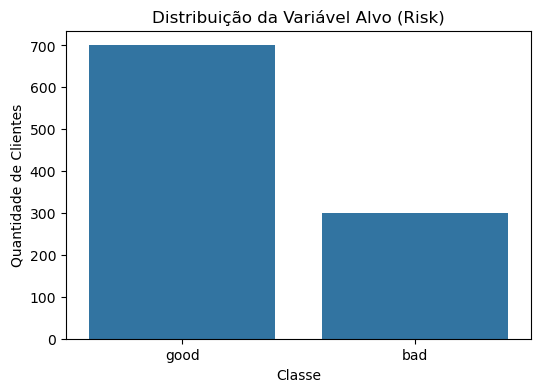

In [16]:
plt.figure(figsize=(6,4))

# Gráfico de barras
sns.countplot(
    data=df,
    x="Risk"
)

plt.title("Distribuição da Variável Alvo (Risk)")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Clientes")

plt.show()

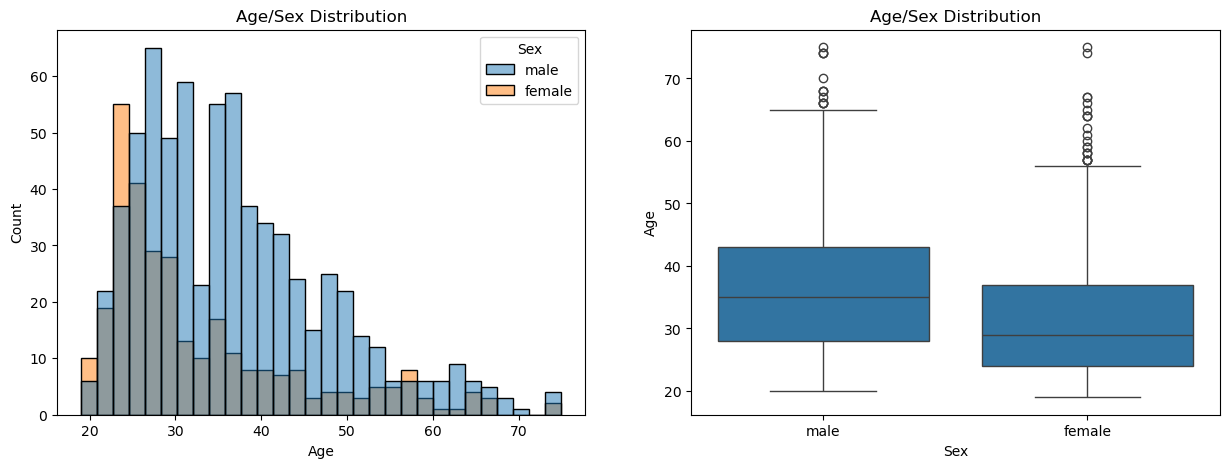

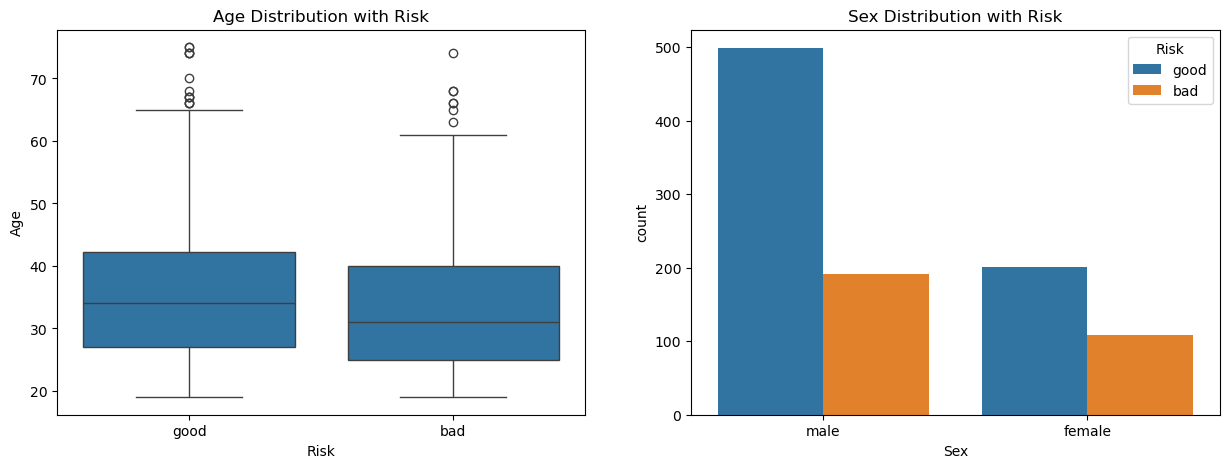

In [17]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.histplot(df, x='Age', bins=30, hue="Sex", ax=ax[0]).set_title("Age/Sex Distribution");
sns.boxplot(data=df, x="Sex", y="Age", ax=ax[1]).set_title("Age/Sex Distribution");

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(data=df, x='Risk', y='Age', ax=ax[0]).set_title("Age Distribution with Risk");
sns.countplot(data=df, x="Sex", hue="Risk", ax=ax[1]).set_title("Sex Distribution with Risk");

- A idade não afeta significativamente a classificação de risco (risk rating).

- Os homens contratam um maior número de créditos no banco.

- Os homens apresentam um percentual menor de classificação ruim (bad rating) do que as mulheres.

In [18]:
df["Age"].skew()

np.float64(1.0207392686768317)

In [19]:
df["Age"].kurt()

np.float64(0.5957795670766881)

In [20]:
df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [21]:
# Estatísticas das variáveis numéricas
numeric_cols = ["Age", "Credit amount", "Duration"]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


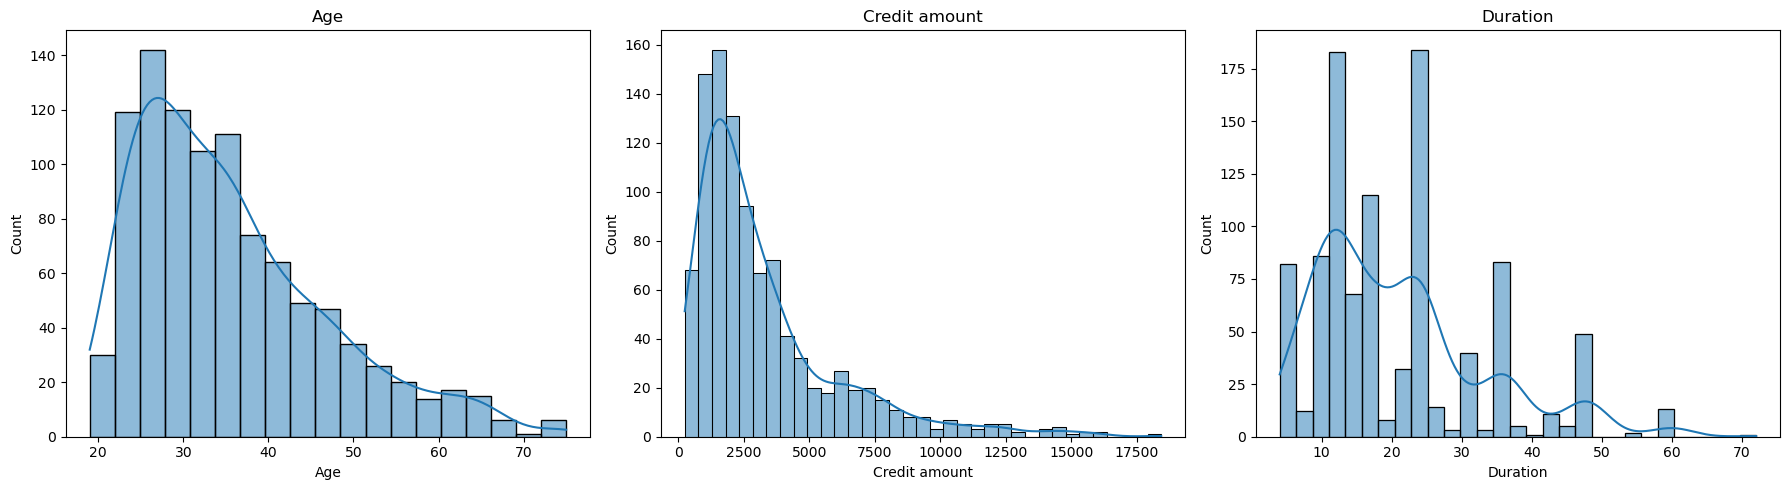

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Age", "Credit amount", "Duration"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

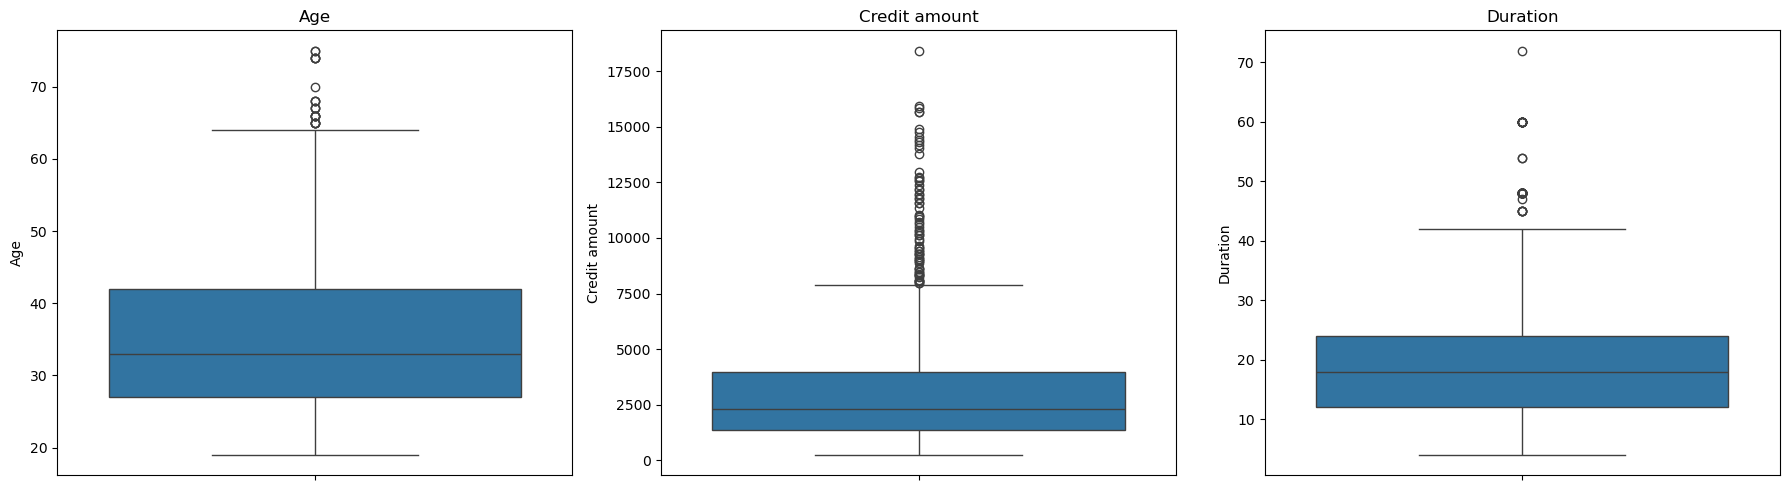

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [24]:
summary = pd.DataFrame({
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})

summary

,Skewness,Kurtosis
Age,1.020739,0.595780
Credit amount,1.949628,4.292590
Duration,1.094184,0.919781


é predominantemente composto por clientes jovens, que pegam pouco dinheiro emprestado, em prazos de curto a médio prazo. 
Qualquer cliente que fuja dessa regra (muito velho, pedindo muito dinheiro ou para pagar em muitos anos) cai na zona de outliers e, como vimos antes, geralmente traz um comportamento de risco diferente.

Age                              Credit amount                   \
     count   mean median    std min max         count     mean  median   
Risk                                                                     
bad    300  33.96   31.0  11.22  19  74           300  3938.13  2574.5   
good   700  36.22   34.0  11.38  19  75           700  2985.46  2244.0   

                          Duration                               
          std  min    max    count   mean median    std min max  
Risk                                                             
bad   3535.82  433  18424      300  24.86   24.0  13.28   6  72  
good  2401.47  250  15857      700  19.21   18.0  11.08   4  60

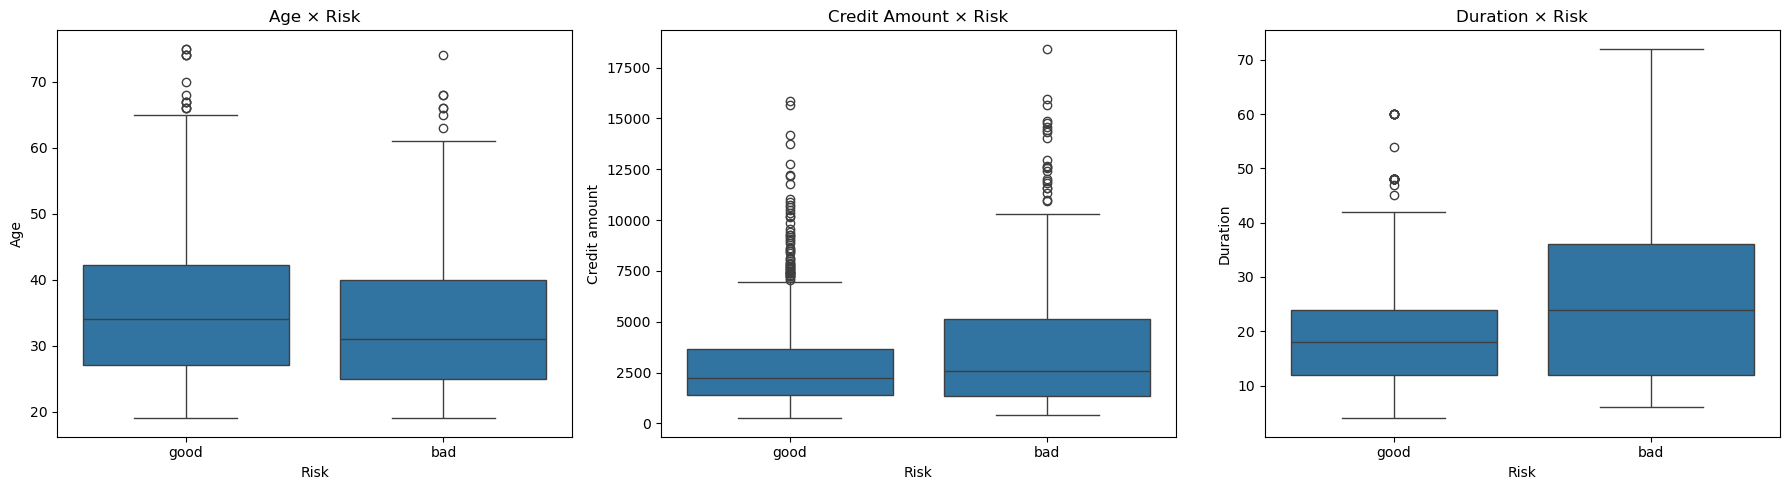

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Estatísticas por classe

display(
    df.groupby("Risk")[["Age", "Credit amount", "Duration"]]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

# Boxplots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.boxplot(data=df, x="Risk", y="Age", ax=axes[0])
axes[0].set_title("Age × Risk")

sns.boxplot(data=df, x="Risk", y="Credit amount", ax=axes[1])
axes[1].set_title("Credit Amount × Risk")

sns.boxplot(data=df, x="Risk", y="Duration", ax=axes[2])
axes[2].set_title("Duration × Risk")

plt.tight_layout()
plt.show()



A análise bivariada indicou que Duration e Credit amount apresentam maior relação com o risco de crédito, enquanto Age possui menor diferenciação entre as classes. Todas as variáveis serão mantidas para que a Random Forest capture seus efeitos combinados.

Sex


Risk,bad,good,All
Sex,,,
female,109,201,310
male,191,499,690
All,300,700,1000


Risk,bad,good
Sex,,
female,35.2,64.8
male,27.7,72.3


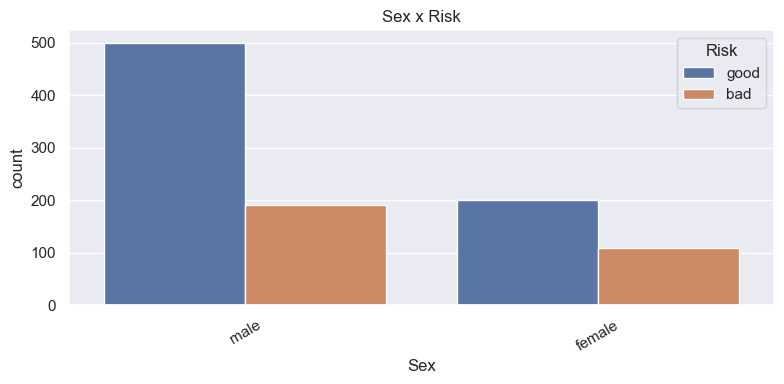

Housing


Risk,bad,good,All
Housing,,,
0,44,64,108
1,70,109,179
2,186,527,713
All,300,700,1000


Risk,bad,good
Housing,,
0,40.7,59.3
1,39.1,60.9
2,26.1,73.9


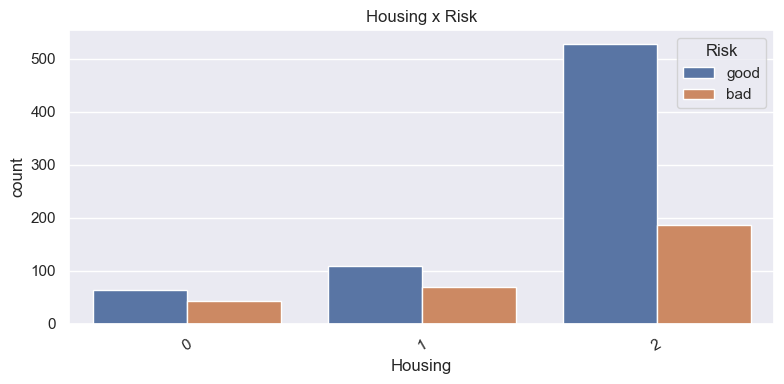

Saving accounts


Risk,bad,good,All
Saving accounts,,,
0,32,151,183
1,217,386,603
2,34,69,103
3,11,52,63
4,6,42,48
All,300,700,1000


Risk,bad,good
Saving accounts,,
0,17.5,82.5
1,36.0,64.0
2,33.0,67.0
3,17.5,82.5
4,12.5,87.5


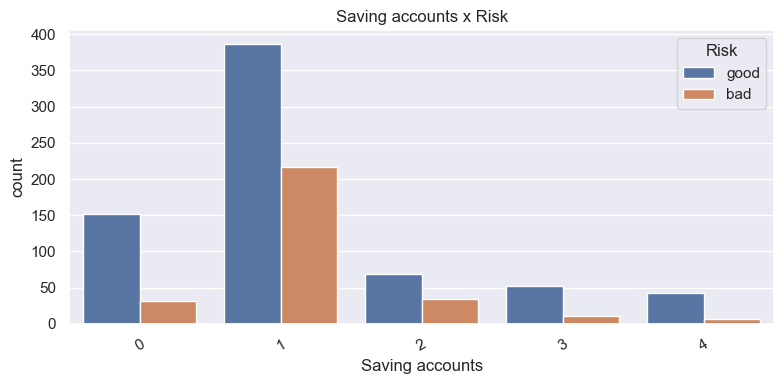

Checking account


Risk,bad,good,All
Checking account,,,
0,46,348,394
1,135,139,274
2,105,164,269
4,14,49,63
All,300,700,1000


Risk,bad,good
Checking account,,
0,11.7,88.3
1,49.3,50.7
2,39.0,61.0
4,22.2,77.8


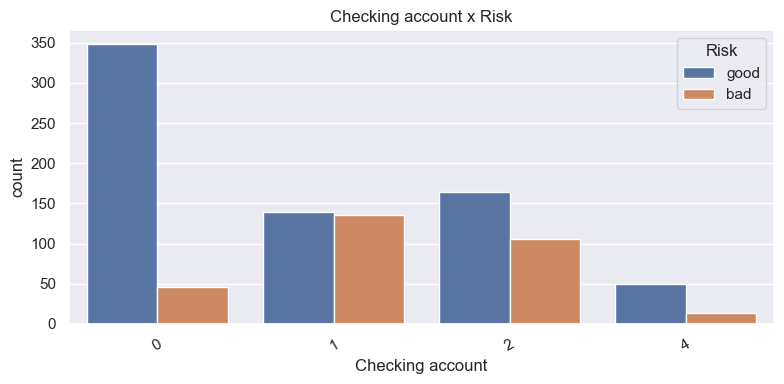

Job


Risk,bad,good,All
Job,,,
0,7,15,22
1,56,144,200
2,186,444,630
3,51,97,148
All,300,700,1000


Risk,bad,good
Job,,
0,31.8,68.2
1,28.0,72.0
2,29.5,70.5
3,34.5,65.5


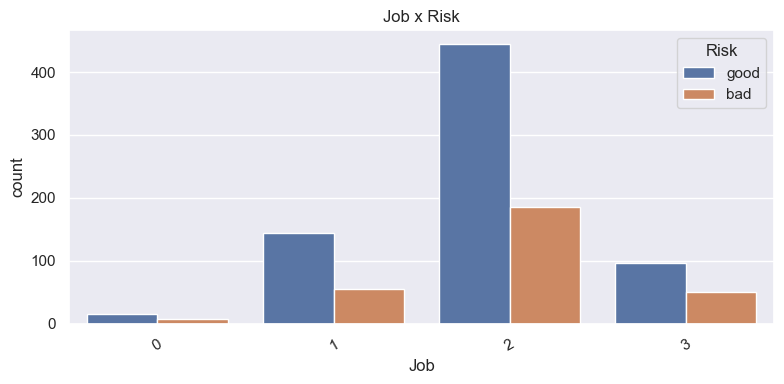

Purpose


Risk,bad,good,All
Purpose,,,
business,34,63,97
car,106,231,337
domestic appliances,4,8,12
education,23,36,59
furniture/equipment,58,123,181
radio/TV,62,218,280
repairs,8,14,22
vacation/others,5,7,12
All,300,700,1000


Risk,bad,good
Purpose,,
business,35.1,64.9
car,31.5,68.5
domestic appliances,33.3,66.7
education,39.0,61.0
furniture/equipment,32.0,68.0
radio/TV,22.1,77.9
repairs,36.4,63.6
vacation/others,41.7,58.3


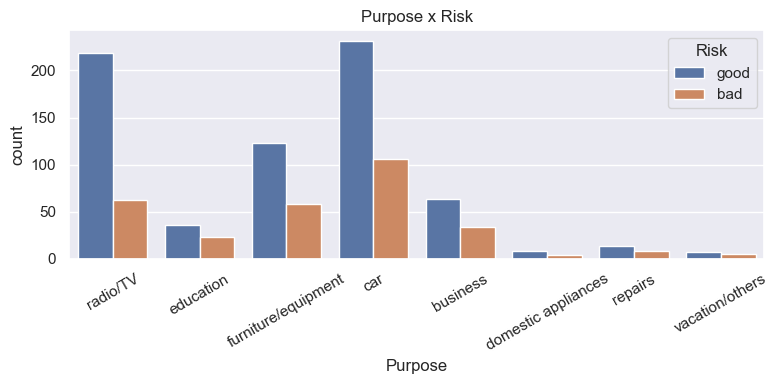

In [34]:
categorical_features = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Job",
    "Purpose"
]

for feature in categorical_features:

    # Tabela de frequências

    print(f"{feature}")

    display(
        pd.crosstab(
            df[feature],
            df["Risk"],
            margins=True
        )
    )

    # Percentual por categoria

    display(
        pd.crosstab(
            df[feature],
            df["Risk"],
            normalize="index"
        ).round(3) * 100
    )

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=feature,
        hue="Risk"
    )

    plt.title(f"{feature} x Risk")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

- Saving accounts apresentou maior relação com risco de crédito.
- Housing também mostrou diferenças relevantes entre os grupos.
- Sex apresentou baixa capacidade de separação entre as classes.
  
Todas as variáveis serão mantidas para a modelagem

Checking account


Risk,bad,good,All
Checking account,,,
0,46,348,394
1,135,139,274
2,105,164,269
4,14,49,63
All,300,700,1000


Risk,bad,good
Checking account,,
0,11.7,88.3
1,49.3,50.7
2,39.0,61.0
4,22.2,77.8


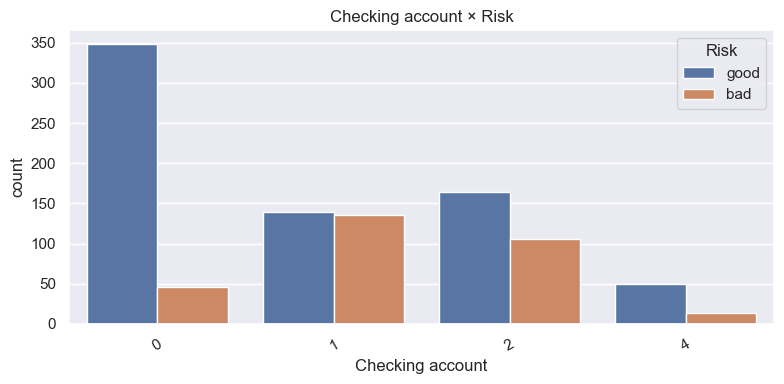

Job


Risk,bad,good,All
Job,,,
0,7,15,22
1,56,144,200
2,186,444,630
3,51,97,148
All,300,700,1000


Risk,bad,good
Job,,
0,31.8,68.2
1,28.0,72.0
2,29.5,70.5
3,34.5,65.5


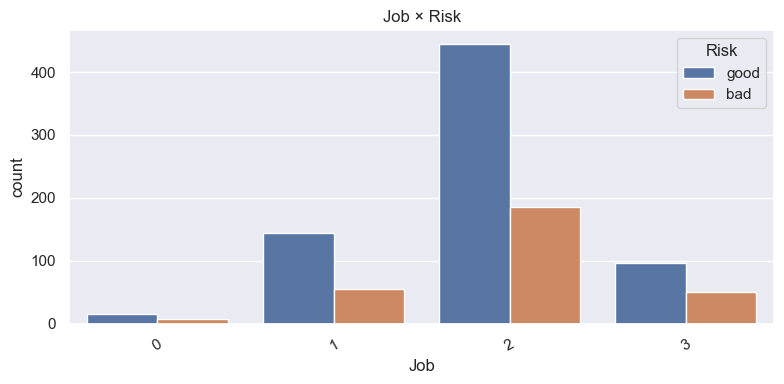

Purpose


Risk,bad,good,All
Purpose,,,
business,34,63,97
car,106,231,337
domestic appliances,4,8,12
education,23,36,59
furniture/equipment,58,123,181
radio/TV,62,218,280
repairs,8,14,22
vacation/others,5,7,12
All,300,700,1000


Risk,bad,good
Purpose,,
business,35.1,64.9
car,31.5,68.5
domestic appliances,33.3,66.7
education,39.0,61.0
furniture/equipment,32.0,68.0
radio/TV,22.1,77.9
repairs,36.4,63.6
vacation/others,41.7,58.3


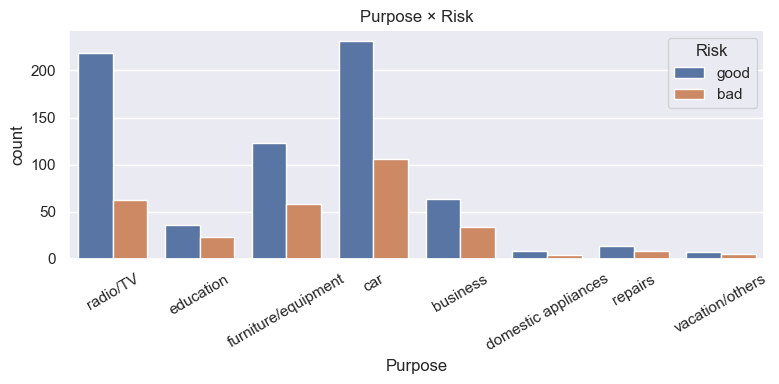

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

categorical_features = [
    "Checking account",
    "Job",
    "Purpose"
]

for feature in categorical_features:

    print(feature)
    
    # Frequência absoluta
    freq = pd.crosstab(df[feature], df["Risk"], margins=True)
    display(freq)

    # Frequência relativa (%)
    perc = (
        pd.crosstab(df[feature], df["Risk"], normalize="index")
        .mul(100)
        .round(1)
    )
    display(perc)

    # Gráfico de contagem
    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=feature,
        hue="Risk"
    )

    plt.title(f"{feature} × Risk")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

- Checking account apresentou maior relação com risco de crédito.
- Purpose mostrou diferenças relevantes entre categorias.
- Job apresentou menor poder preditivo isolado.
    
Todas as variáveis serão mantidas para a Random Forest avaliar sua contribuição conjunta.

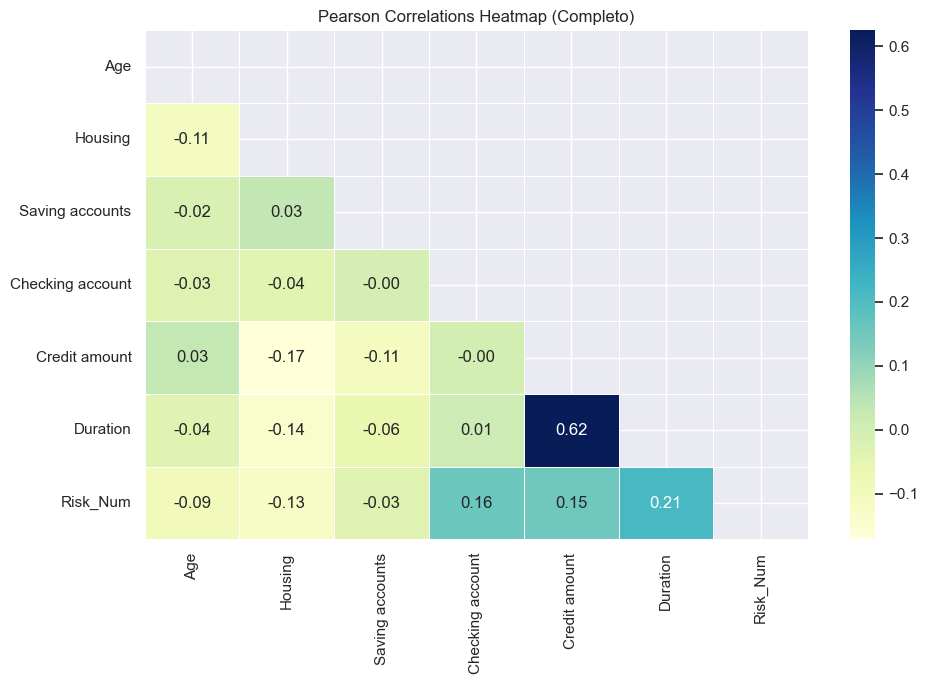

In [32]:
df_heatmap = pd.read_csv("../data/german_credit_data.csv", index_col=0)

def SC_LabelEncoder(x):
    val = str(x).lower()
    if "little" in val: return 1
    elif "moderate" in val: return 2
    elif "quite rich" in val: return 3
    elif "rich" in val: return 4
    else: return 0

def H_LabelEncoder(x):
    val = str(x).lower()
    if "free" in val: return 0
    elif "rent" in val: return 1
    elif "own" in val: return 2
    else: return 0

df_heatmap["Saving accounts"] = df_heatmap["Saving accounts"].apply(SC_LabelEncoder)
df_heatmap["Checking account"] = df_heatmap["Checking account"].apply(SC_LabelEncoder)
df_heatmap["Housing"] = df_heatmap["Housing"].apply(H_LabelEncoder)

df_heatmap['Risk_Num'] = df_heatmap['Risk'].map({'good': 0, 'bad': 1})

cols = ['Age', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Risk_Num']
corr = df_heatmap[cols].corr()

plt.figure(figsize=(10,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="YlGnBu", linewidths=.5, fmt=".2f")
plt.title("Pearson Correlations Heatmap (Completo)")
plt.tight_layout()
plt.show()

O valor do crédito está altamente relacionado à duração.